# This notebook




Is divided up like this:

---

Task X

Python code for solving the task

Findings/suggestion to what we should write in overleaf

---

## Task one - Exploration of data

Data Exploration (10)

> a. Explore the dataset by displaying the first few rows, summary statistics, and data
types of each column.

> b. Identify missing values, outliers, and unique values in categorical columns.

In [1]:
# importing stuff and defining the csv https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
import pandas as pd
import matplotlib.pyplot as plt # For plotting
from scipy.stats import zscore # For calculating z-scores, evt andre ting vi trenger
import numpy as np


datafile= r"../data/smoking_driking_dataset_Ver01.csv"
df = pd.read_csv(datafile)

In [2]:
print("Example sample of how the data looks like")
df.head()

Example sample of how the data looks like


,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N


In [3]:
# Table with overall information on the data

print("===== OVERALL INFO =====") # https://www.w3schools.com/python/pandas/ref_df_info.asp

print(f"Observations: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")

if df.isnull().sum().sum() == 0:
    print("No missing values in the dataset.\n")
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])

print("Table with columns")
info_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values, # Datatype
    "Missing": df.isnull().sum().values, # See if any missing values
    "Unique Values": df.nunique().values # Number of unique values, those with low are liekly categorical values like, male/female, yes/no https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nunique.html
})

display(info_table)

===== OVERALL INFO =====
Observations: 991,346
Variables: 24
No missing values in the dataset.

Table with columns


,Column,Data Type,Missing,Unique Values
0,sex,str,0,2
1,age,int64,0,14
2,height,int64,0,13
3,weight,int64,0,24
4,waistline,float64,0,737
5,sight_left,float64,0,24
6,sight_right,float64,0,24
7,hear_left,float64,0,2
8,hear_right,float64,0,2
9,SBP,float64,0,171


In [4]:
# Statistics per column
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,991346.0,47.614491,14.181339,20.0,35.0,45.0,60.0,85.0
height,991346.0,162.240625,9.282957,130.0,155.0,160.0,170.0,190.0
weight,991346.0,63.284050,12.514241,25.0,55.0,60.0,70.0,140.0
waistline,991346.0,81.233358,11.850323,8.0,74.1,81.0,87.8,999.0
sight_left,991346.0,0.980834,0.605949,0.1,0.7,1.0,1.2,9.9
sight_right,991346.0,0.978429,0.604774,0.1,0.7,1.0,1.2,9.9
hear_left,991346.0,1.031495,0.174650,1.0,1.0,1.0,1.0,2.0
hear_right,991346.0,1.030476,0.171892,1.0,1.0,1.0,1.0,2.0
SBP,991346.0,122.432498,14.543148,67.0,112.0,120.0,131.0,273.0
DBP,991346.0,76.052627,9.889365,32.0,70.0,76.0,82.0,185.0


In [5]:
# Tolker dem slikt: DRK_YN: Do you drink, yes/no? 
# SMK_stat_...:
# Do you smoke? 1: Never smoked, 2 I used to smoke but have now stopped, 3: I currently smoke

# Data on main categories

print("Sex")
print(f"Male: {df['sex'].value_counts()['Male']:,}")
print(f"Female: {df['sex'].value_counts()['Female']:,}")

print("\nAlcohol")
print(f"Drinks: {df['DRK_YN'].value_counts()['Y']:,}")
print(f"Does not drink: {df['DRK_YN'].value_counts()['N']:,}")

smoking = df["SMK_stat_type_cd"].value_counts()

print("\nSmoking")
print(f"Never smoked: {smoking[1.0]:,}")
print(f"Former smoker: {smoking[2.0]:,}")
print(f"Current smoker: {smoking[3.0]:,}")

Sex
Male: 526,415
Female: 464,931

Alcohol
Drinks: 495,488
Does not drink: 495,858

Smoking
Never smoked: 602,441
Former smoker: 174,951
Current smoker: 213,954


In [6]:
# Summary statistics

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].describe().T[
    ["min", "25%", "50%", "75%", "max"]
]

,min,25%,50%,75%,max
age,20.0,35.0,45.0,60.0,85.0
height,130.0,155.0,160.0,170.0,190.0
weight,25.0,55.0,60.0,70.0,140.0
waistline,8.0,74.1,81.0,87.8,999.0
sight_left,0.1,0.7,1.0,1.2,9.9
sight_right,0.1,0.7,1.0,1.2,9.9
hear_left,1.0,1.0,1.0,1.0,2.0
hear_right,1.0,1.0,1.0,1.0,2.0
SBP,67.0,112.0,120.0,131.0,273.0
DBP,32.0,70.0,76.0,82.0,185.0


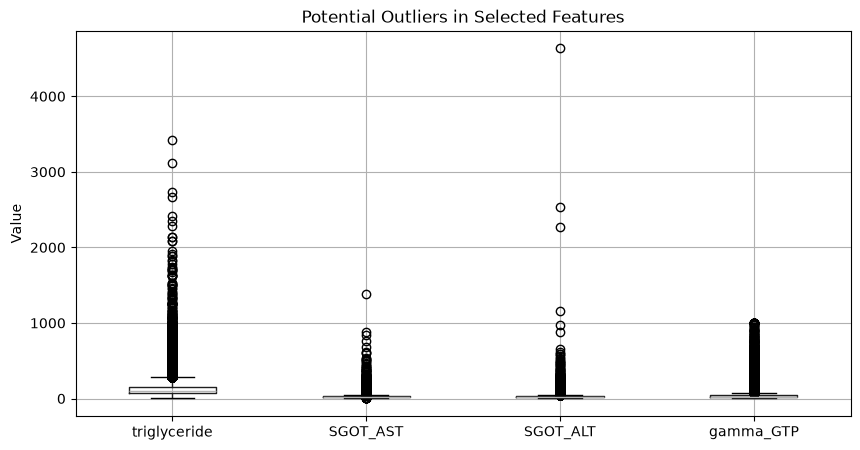

In [7]:
sample = df.sample(100000, random_state=42)

sample[
    ["triglyceride", "SGOT_AST", "SGOT_ALT", "gamma_GTP"]
].boxplot(figsize=(10, 5))

plt.title("Potential Outliers in Selected Features")
plt.ylabel("Value")
plt.show()

### Suggested writings task 1:


2 Data Exploration
The dataset contains 991,346 observations and 24 variables. Most variables
are numerical health measurements, including age, blood pressure, cholesterol,
triglycerides, blood glucose, and liver enzyme measurements. The dataset also
contains categorical variables describing sex, alcohol consumption, and smoking
status.

2.1 Dataset Structure
The dataset contains 19 variables stored as float64, 3 as int64, and 2 as
strings. Although SMK stat type cd is stored numerically, it represents three
smoking categories rather than a continuous measurement.
The main categorical variables are summarized below:
No missing values were found in any of the 24 variables.

2.2 Summary Statistics and Potential Outliers
The summary statistics indicate that several variables contain values far above
their typical ranges. For example, the 75th percentile of triglyceride is 159,
while the maximum value is 9,490. Similarly, SGOT AST has a 75th percentile of
28 and a maximum of 9,999, while SGOT ALT has a 75th percentile of 29 and a
maximum of 7,210.

- Table of the categories sex, alcohol yes/no, smoking never/former/current

- Then the graph with potential outliers

- brief explanation

## Task 2 Data Cleaning

Data Cleaning (20)
> a. Handling Missing Values

> b. Choose appropriate methods to handle missing values (e.g., mean/median imputation for numerical data, mode imputation for categorical data, or deletion of rows/columns).

> c. Justify your choices for handling missing data.


**(NB!) Comment:**

To solve this we should find another because there is no missing values in the smoking-drinking one.
We could be lazy and say there was no missing data, but to show that we know how to properly handle missing data we need another dataset for this task and explain it.


In [8]:

# FOR THE DATASET SMOKING/DRINKING

# Missing values
print(f"Missing values: {df.isnull().sum().sum()}")

# Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

df = df.drop_duplicates()

print(f"Rows after cleaning: {len(df):,}")

Missing values: 0
Duplicate rows: 26
Rows after cleaning: 991,320


## Task 3 outliers something


Handling Outliers (20)

> a. Detect outliers using methods such as the IQR method or Z-score.

> b. Decide whether to remove, cap, or transform the outliers. Justify your decisions.


comparing iqr to z score

"The Interquartile Range (IQR) is a measure of statistical dispersion that describes the spread of the middle 50% of a dataset." https://www.geeksforgeeks.org/dsa/interquartile-range-iqr/

In [9]:
# Outlier detection using IQR and Z-score methods for all columns in the dataset.

columns = [
    "age",
    "height",
    "weight",
    "waistline",
    "sight_left",
    "sight_right",
    "SBP",
    "DBP",
    "BLDS",
    "tot_chole",
    "HDL_chole",
    "LDL_chole",
    "triglyceride",
    "hemoglobin",
    "serum_creatinine",
    "SGOT_AST",
    "SGOT_ALT",
    "gamma_GTP"
]

results = []

for col in columns:

    # IQR method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    iqr_count = ((df[col] < lower) | (df[col] > upper)).sum()

    # Z-score method
    z = np.abs(zscore(df[col]))
    z_count = (z > 3).sum()

    results.append({
        "Column": col,
        "IQR Outliers": iqr_count,
        "IQR %": iqr_count / len(df) * 100,
        "Z-score Outliers": z_count,
        "Z-score %": z_count / len(df) * 100
    })

outlier_comparison = pd.DataFrame(results)

outlier_comparison = outlier_comparison.sort_values(
    "IQR %",
    ascending=False
)

display(
    outlier_comparison.style.format({
        "IQR %": "{:.2f}%",
        "Z-score %": "{:.2f}%"
    })
)


,Column,IQR Outliers,IQR %,Z-score Outliers,Z-score %
17,gamma_GTP,94141,9.50%,15360,1.55%
16,SGOT_ALT,72928,7.36%,10370,1.05%
15,SGOT_AST,67614,6.82%,5887,0.59%
8,BLDS,64198,6.48%,18619,1.88%
12,triglyceride,54098,5.46%,14627,1.48%
2,weight,19217,1.94%,4579,0.46%
6,SBP,15835,1.60%,6422,0.65%
10,HDL_chole,13858,1.40%,3877,0.39%
7,DBP,13121,1.32%,6204,0.63%
4,sight_left,11581,1.17%,3118,0.31%


In [10]:
# Top 5 "worst" as in highest detected outlier percentage

outlier_comparison["Worst %"] = outlier_comparison[
    ["IQR %", "Z-score %"]
].max(axis=1)

worst = outlier_comparison.sort_values(
    "Worst %",
    ascending=False
)

display(
    worst.head(5).style.format({
        "IQR %": "{:.2f}%",
        "Z-score %": "{:.2f}%",
        "Worst %": "{:.2f}%"
    })
)

,Column,IQR Outliers,IQR %,Z-score Outliers,Z-score %,Worst %
17,gamma_GTP,94141,9.50%,15360,1.55%,9.50%
16,SGOT_ALT,72928,7.36%,10370,1.05%,7.36%
15,SGOT_AST,67614,6.82%,5887,0.59%,6.82%
8,BLDS,64198,6.48%,18619,1.88%,6.48%
12,triglyceride,54098,5.46%,14627,1.48%,5.46%


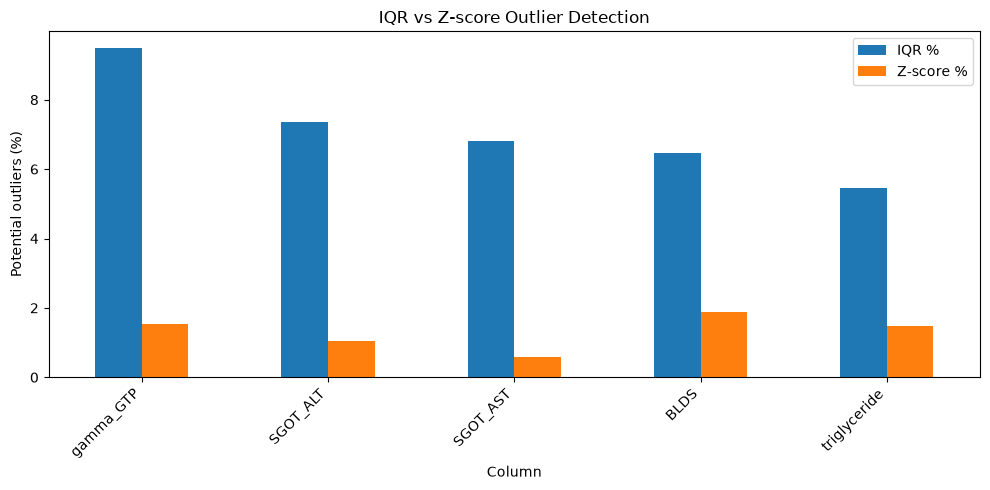

In [11]:
worst_features = worst.head(5)["Column"]

comparison_plot = (
    outlier_comparison
    .set_index("Column")
    .loc[worst_features, ["IQR %", "Z-score %"]]
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Potential outliers (%)")
plt.title("IQR vs Z-score Outlier Detection")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
worst_features = worst.head(5)["Column"].tolist()

display(
    df[worst_features]
    .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
gamma_GTP,991320.0,37.136152,50.423811,1.0,8.0,16.0,23.0,39.0,105.0,232.0,999.0
SGOT_ALT,991320.0,25.755148,26.308910,1.0,7.0,15.0,20.0,29.0,59.0,106.0,7210.0
SGOT_AST,991320.0,25.989424,23.493668,1.0,12.0,19.0,23.0,28.0,46.0,79.0,9999.0
BLDS,991320.0,100.424305,24.179852,25.0,71.0,88.0,96.0,105.0,137.0,204.0,852.0
triglyceride,991320.0,132.140030,102.194762,1.0,34.0,73.0,106.0,159.0,297.0,499.0,9490.0


In [13]:
skewness = df[worst_features].skew().sort_values(
    ascending=False
)

display(skewness)

SGOT_AST        150.490203
SGOT_ALT         50.038404
gamma_GTP         7.718657
triglyceride      6.529776
BLDS              4.617495
dtype: float64

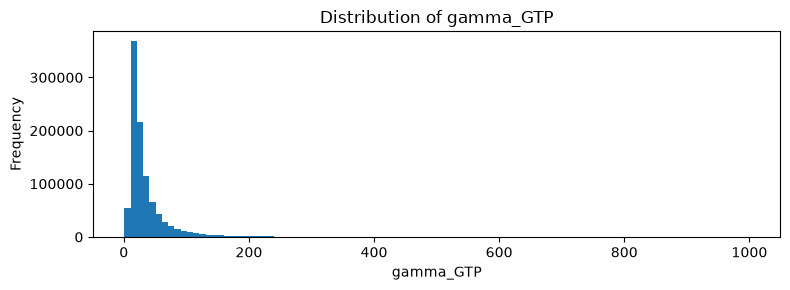

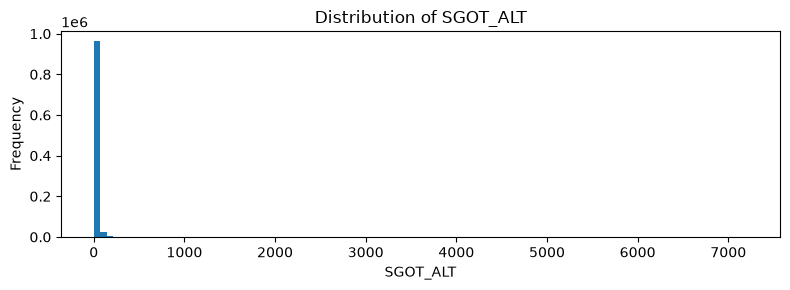

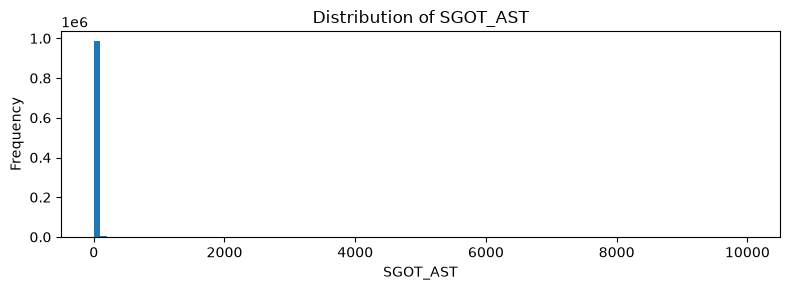

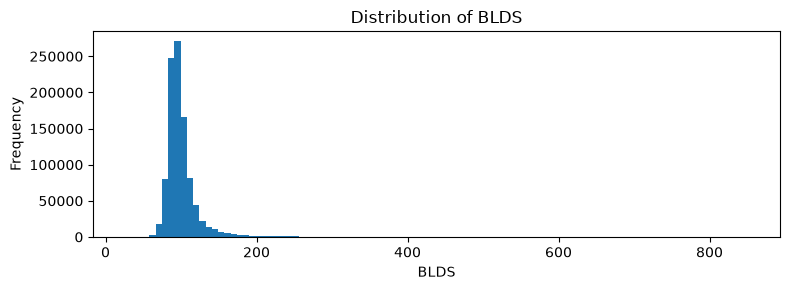

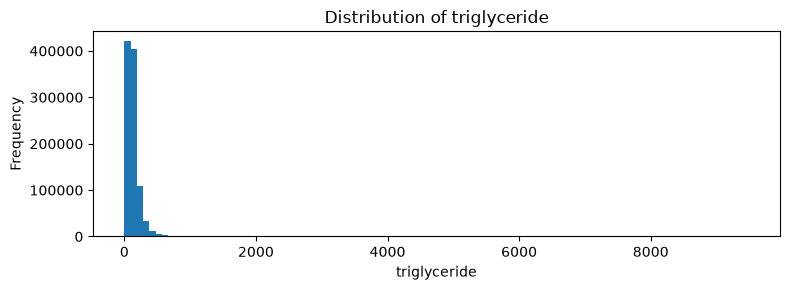

In [14]:
for col in worst_features:
    plt.figure(figsize=(8, 3))

    plt.hist(df[col], bins=100)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

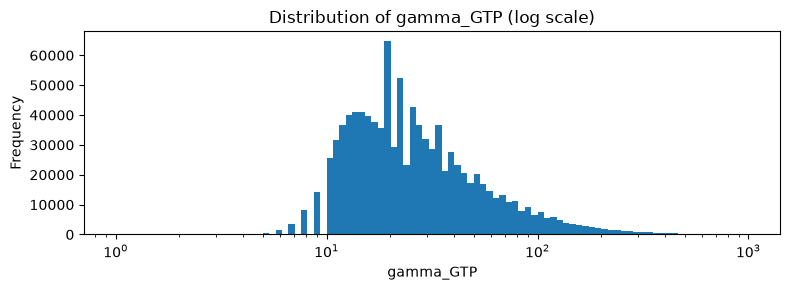

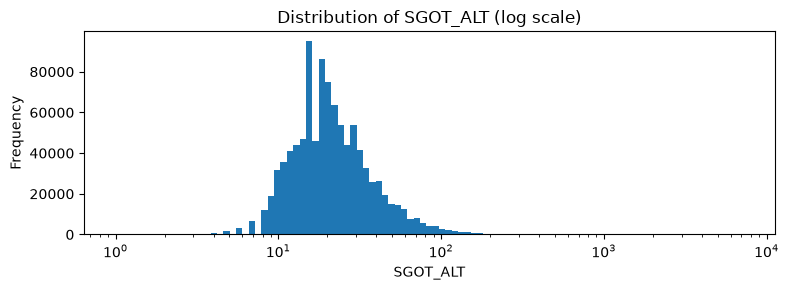

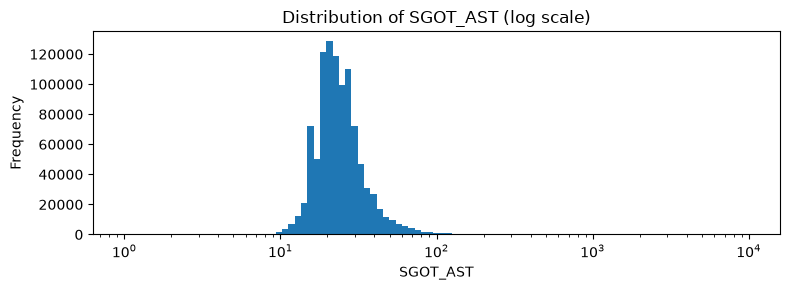

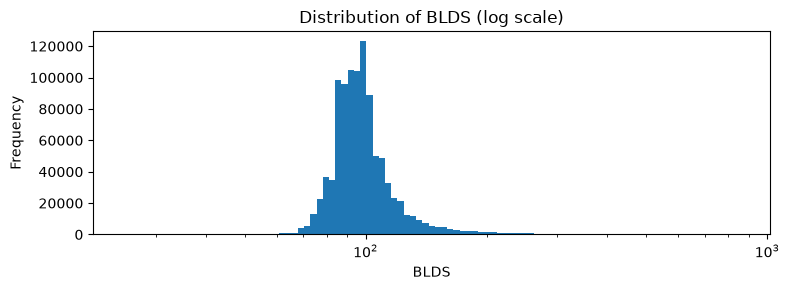

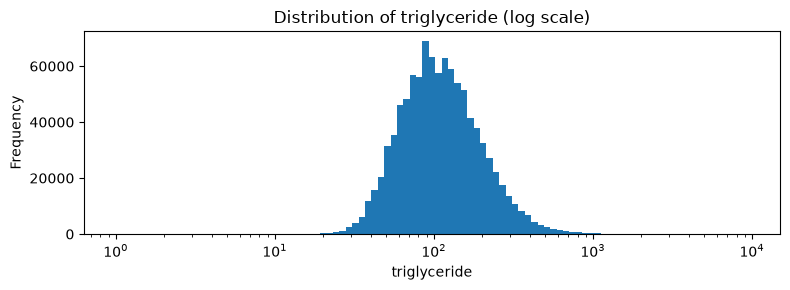

In [15]:
# The last ones just logarithmically scaled

for col in worst_features:
    values = df[col][df[col] > 0]

    bins = np.logspace(
        np.log10(values.min()),
        np.log10(values.max()),
        100
    )

    plt.figure(figsize=(8, 3))
    plt.hist(values, bins=bins)

    plt.xscale("log")
    plt.title(f"Distribution of {col} (log scale)")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [16]:
log_columns = [
    "gamma_GTP",
    "SGOT_ALT",
    "SGOT_AST",
    "BLDS",
    "triglyceride"
]

# Skewness before transformation
skew_before = df[log_columns].skew()

# Create a copy so the original dataframe is not changed
df_log = df.copy()

# Apply logarithmic transformation
for col in log_columns:
    df_log[col] = np.log1p(df_log[col])

# Skewness after transformation
skew_after = df_log[log_columns].skew()

# Compare results
skewness_comparison = pd.DataFrame({
    "Before log transformation": skew_before,
    "After log transformation": skew_after
})

display(skewness_comparison)

,Before log transformation,After log transformation
gamma_GTP,7.718657,1.021365
SGOT_ALT,50.038404,0.775826
SGOT_AST,150.490203,1.427051
BLDS,4.617495,2.033597
triglyceride,6.529776,0.420522


In [17]:
from scipy.stats import boxcox

blds_boxcox, fitted_lambda = boxcox(df["BLDS"])

print("Original:", df["BLDS"].skew())
print("Log1p:", np.log1p(df["BLDS"]).skew())
print("Box-Cox:", pd.Series(blds_boxcox).skew())
print("Lambda:", fitted_lambda)

Original: 4.617495260978581
Log1p: 2.0335967181879298
Box-Cox: -0.24482839575638007
Lambda: -1.8043454919997968



### Explanation of results

For outlier detection I used both IQR and Z-score 

Short explanation of results


A)

* Most affected features: `gamma_GTP`, `SGOT_ALT`, `SGOT_AST`, `BLDS`, `triglyceride`.
They were chosen as they had outlier rates between 5-9%, compared to next which was weight at <2%

* IQR vs Z-score: IQR detected more potential outliers, especially in right-skewed variables.
* Interpretation: Statistical outliers are not automatically incorrect values.
* Skewness: All five selected features were strongly right-skewed. (which means most are in a cluster of small values, but there are some larger values which stretch the distribution to the right. compare 99% with max and youll see)


B)

This is medical data as well as we dont have domain knowledge or any knowledge on how the data was taken, so it would be wrong to just cap or remove as we dont have any evidence there were any errors. 
* No removal/capping: Extreme observations were retained because there was no evidence that they were data errors.

Therefore I chose to log transform them, because it is more aggressive for higher values compared to lower ones.
e.g.:

23 -> log1p = 3.18

79 -> log1p = 4.38

9999 -> log1p = 9.21

* Treatment: `gamma_GTP`, `SGOT_ALT`, `SGOT_AST`, and `triglyceride` were log-transformed with `log1p`.

When it came to BLDS, 
For BLDS, log transformation reduced skewness from 4.62 to 2.03, but the distribution still remained skewed.
I tried box-cox and it went from 4.62 to -0.24 which makes it much better


Below there are some graphs used for the report


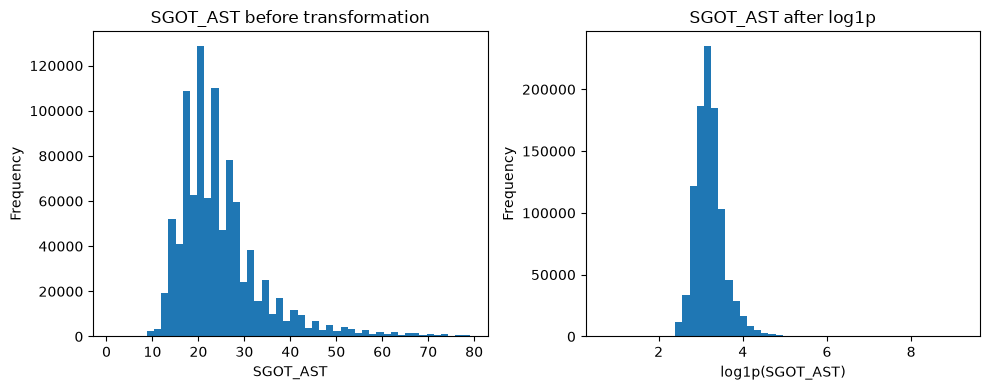

In [18]:
# These are for the report:

limit = df["SGOT_AST"].quantile(0.99)

# Only for plotting
sgot_plot = df.loc[df["SGOT_AST"] <= limit, "SGOT_AST"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Original distribution, first 99%
axes[0].hist(sgot_plot, bins=50)
axes[0].set_title("SGOT_AST before transformation")
axes[0].set_xlabel("SGOT_AST")
axes[0].set_ylabel("Frequency")

# Log-transformed full dataset
axes[1].hist(np.log1p(df["SGOT_AST"]), bins=50)
axes[1].set_title("SGOT_AST after log1p")
axes[1].set_xlabel("log1p(SGOT_AST)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

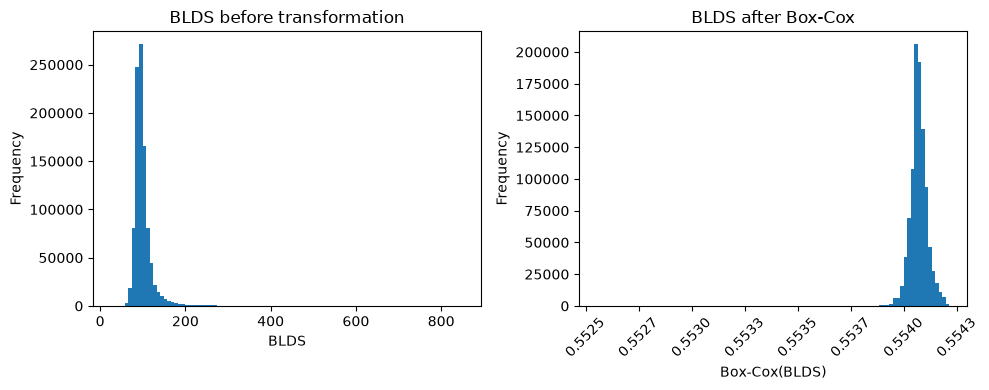

In [19]:
# These are for the report:

from scipy.stats import boxcox
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

blds_boxcox, fitted_lambda = boxcox(df["BLDS"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df["BLDS"], bins=100)
axes[0].set_title("BLDS before transformation")
axes[0].set_xlabel("BLDS")
axes[0].set_ylabel("Frequency")

axes[1].hist(blds_boxcox, bins=100)
axes[1].set_title("BLDS after Box-Cox")
axes[1].set_xlabel("Box-Cox(BLDS)")
axes[1].set_ylabel("Frequency")

# Rotate the x-axis labels by 45 degrees to prevent overlap
axes[1].tick_params(axis='x', rotation=45)

# Limit the decimal precision to a specific number of places (e.g., 4)
axes[1].xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.show()

In [20]:
# Applying the transformations to the dataset:

import numpy as np
from scipy.stats import boxcox

log_columns = [
    "gamma_GTP",
    "SGOT_ALT",
    "SGOT_AST",
    "triglyceride"
]

# Apply log transformation directly to df
for col in log_columns:
    df[col] = np.log1p(df[col])

# Apply Box–Cox transformation directly to BLDS
df["BLDS"], bl_ds_lambda = boxcox(df["BLDS"])

print(f"Applied log transformation to columns: {log_columns} and Box-Cox transformation to 'BLDS' with lambda: {bl_ds_lambda:.4f}")

Applied log transformation to columns: ['gamma_GTP', 'SGOT_ALT', 'SGOT_AST', 'triglyceride'] and Box-Cox transformation to 'BLDS' with lambda: -1.8043


## Task 4 goes here